# TP · Du perceptron au MLP

Ce notebook reprend les concepts de la matinée et les met en code, de la brique la plus
simple jusqu'à un réseau qui reconnaît des chiffres manuscrits.

On part d'un perceptron écrit à la main, on voit pourquoi il échoue sur XOR, puis on
construit un vrai réseau en PyTorch et on mesure ce qui le fait apprendre. On finit en le
cassant, pour voir ce qu'il n'a jamais appris.

**4 exercices, une dizaine de lignes à écrire.** Si tu bloques, prends le corrigé et
avance : l'essentiel se joue dans les graphiques.

Le code reprend la notation du matin : `x`, `w`, `b`, `z`, `y_chapeau`, `eta`.

In [1]:
import pathlib
import sys

# Racine du dépôt, qu'on lance ce notebook depuis notebooks/ ou notebooks/solutions/.
RACINE = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
              if (p / "src" / "mnist.py").exists())
sys.path.insert(0, str(RACINE / "src"))

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader

import mnist
import viz
from couleurs import applique_style, BLEU, VIOLET

applique_style()
np.random.seed(0)
torch.manual_seed(0)

print("PyTorch", torch.__version__, ": on reste sur CPU, c'est suffisant ici.")

PyTorch 2.13.0+cu130 : on reste sur CPU, c'est suffisant ici.


---
# 1 · Le perceptron, et XOR

XOR vaut 1 quand **exactement une** des deux entrées vaut 1.

| x₁ | x₂ | y |
|----|----|---|
| 0  | 0  | 0 |
| 0  | 1  | 1 |
| 1  | 0  | 1 |
| 1  | 1  | 0 |

Regarde les 4 points ci-dessous et essaie de tracer une seule droite qui sépare les bleus
des violets.

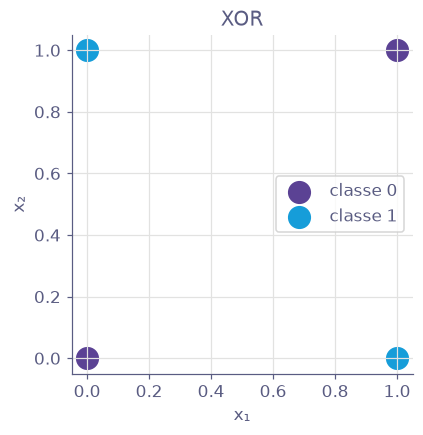

In [2]:
X_xor = np.array([[0.0, 0.0], [0.0, 1.0], [1.0, 0.0], [1.0, 1.0]])
y_xor = np.array([0, 1, 1, 0])

plt.figure(figsize=(4, 4))
for classe, couleur in [(0, VIOLET), (1, BLEU)]:
    points = X_xor[y_xor == classe]
    plt.scatter(points[:, 0], points[:, 1], c=couleur, s=200, label=f"classe {classe}")
plt.xlabel("x₁"); plt.ylabel("x₂"); plt.title("XOR")
plt.legend(); plt.show()

### Exercice 1 · la fonction seuil

$$\hat{y} = f(z) = \begin{cases} 1 & \text{si } z \geq 0 \\ 0 & \text{sinon}\end{cases}
\qquad z = w \cdot x + b$$

In [5]:
def seuil(z):
    """1 si z >= 0, 0 sinon. Marche aussi sur un tableau."""
    # ✏️ À TOI DE JOUER — renvoie 1 quand z >= 0 et 0 sinon (np.where t'aide)
    return np.where(z >= 0, 1, 0)


def predit(x, w, b):
    """Prédiction du perceptron pour un exemple x, ou pour un lot d'exemples."""
    # ✏️ À TOI DE JOUER — calcule z = w · x + b, puis applique seuil()
    z = np.dot(x, w) + b  # Le produit scalaire, cœur du neurone
    return seuil(z)


# Avec ces poids-là, le neurone doit calculer le OU logique.
assert list(predit(X_xor, np.array([1.0, 1.0]), -0.5)) == [0, 1, 1, 1]
print("OK : ce neurone calcule le OU logique. Pas encore XOR.")

OK : ce neurone calcule le OU logique. Pas encore XOR.


### Exercice 2 · la règle de mise à jour

Celle du matin, à l'identique :

$$w \leftarrow w + \eta \cdot (y - \hat{y}) \cdot x
\qquad
b \leftarrow b + \eta \cdot (y - \hat{y})$$

| Situation | `y - y_chapeau` | Effet sur `w` |
|---|---|---|
| bonne prédiction | 0 | rien ne bouge |
| on attendait 1, on a prédit 0 | +1 | on augmente |
| on attendait 0, on a prédit 1 | −1 | on diminue |

erreurs sur les 10 dernières époques : [4, 4, 4, 4, 4, 4, 4, 4, 4, 4]


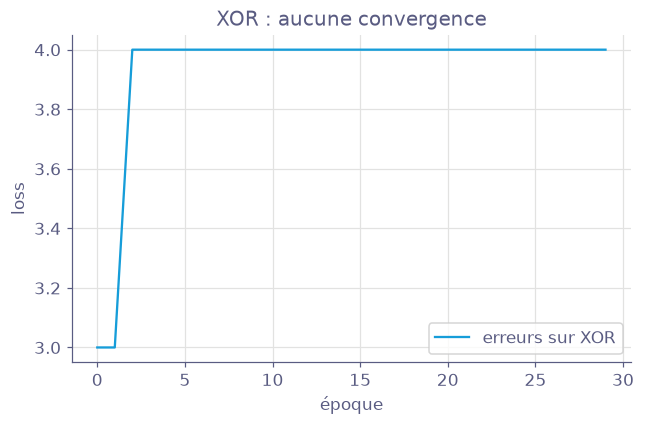

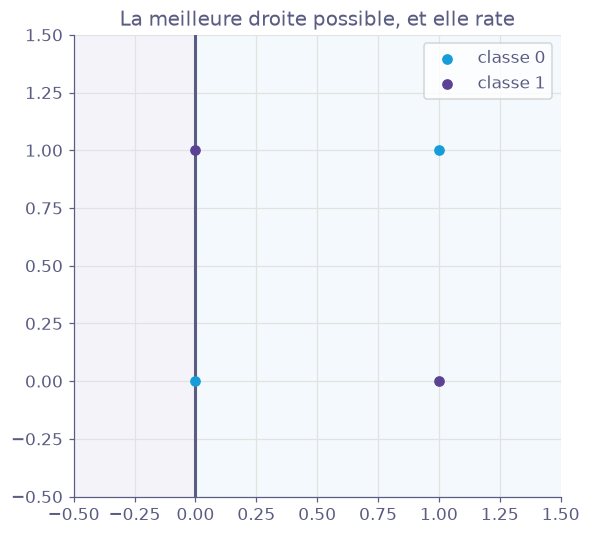

In [7]:
def entraine_perceptron(X, y, eta=0.1, epoques=20):
    """Entraîne un perceptron. Renvoie (w, b, erreurs_par_epoque)."""
    w, b, erreurs = np.zeros(X.shape[1]), 0.0, []

    for _ in range(epoques):
        n_erreurs = 0
        for x, y_vrai in zip(X, y):
            y_chapeau = predit(x, w, b)

            # ✏️ À TOI DE JOUER — applique les deux formules ci-dessus
            # Formules de mise à jour
            delta = y_vrai - y_chapeau
            w += eta * delta * x
            b += eta * delta

            n_erreurs += int(y_chapeau != y_vrai)
        erreurs.append(n_erreurs)

    return w, b, erreurs


w, b, erreurs = entraine_perceptron(X_xor, y_xor, eta=0.1, epoques=30)
print("erreurs sur les 10 dernières époques :", erreurs[-10:])

viz.plot_courbes({"erreurs sur XOR": erreurs}, titre="XOR : aucune convergence")
viz.montre_frontiere(X_xor, y_xor, w, b, titre="La meilleure droite possible, et elle rate")

Le nombre d'erreurs ne descend jamais à 0. Il oscille.

Ni bug, ni `eta` mal réglé : aucun couple (`w`, `b`) ne satisfait les 4 points à la fois,
puisqu'un perceptron ne trace **qu'une seule droite**. C'est la limite vue ce matin, celle
qui oblige à combiner plusieurs neurones.

---
# 2 · Le perceptron sur MNIST

Une droite ne suffit pas pour séparer les points dans le cas de XOR. Mais pour séparer un 0
d'un 1, ça devrait aller.

Avant de charger les données, deux décisions de préparation à comprendre.

**Aplatir en 784.** Le neurone attend un vecteur `x`, pas une grille : `28 × 28 = 784`
pixels. Retiens cette ligne, on va l'accuser à la fin du notebook.

**Normaliser, c'est-à-dire diviser par 255.** Le pas de mise à jour vaut
`eta * (y - ŷ) * x`, donc il est proportionnel à `x`. Avec des pixels à 255, les pas sont
255 fois trop grands.

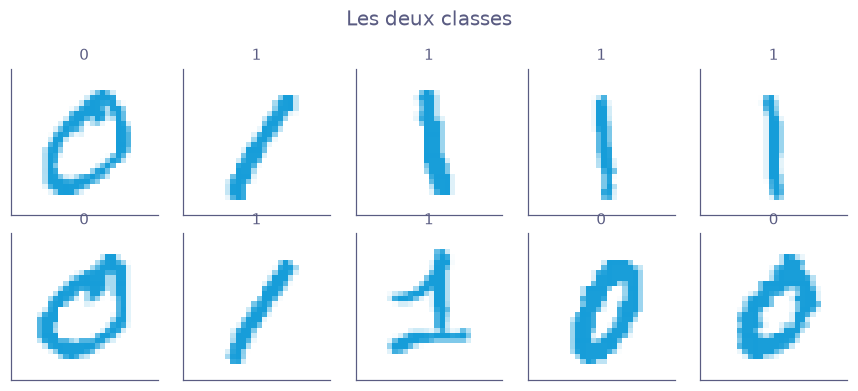

accuracy sur le jeu de test : 99.86%


In [8]:
X_train01, y_train01, X_test01, y_test01 = mnist.charge_mnist(
    aplati=True, normalise=True, sous_ensemble=[0, 1]
)
viz.affiche_chiffres(X_train01, y_train01, n=10, titre="Les deux classes")

w01, b01, _ = entraine_perceptron(X_train01, y_train01, eta=0.01, epoques=3)
accuracy = (predit(X_test01, w01, b01) == y_test01).mean()
print(f"accuracy sur le jeu de test : {accuracy:.2%}")
assert accuracy > 0.99

### Le graphique à ne pas rater

`w` a 784 composantes, une par pixel. Il se replie donc en une image 28×28.

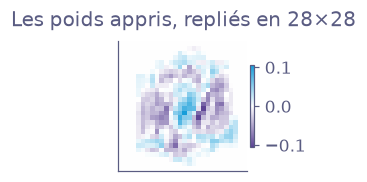

In [9]:
viz.montre_poids(w01, titre="Les poids appris, repliés en 28×28")

Les poids ne sont pas une abstraction, ce sont des pixels :

- **bleu** : de l'encre ici pousse vers la classe 1 (la barre du **1**) ;
- **violet** : pousse vers la classe 0 (l'anneau du **0**) ;
- **blanc** : poids nul, pixels inutiles (les bords).

`w · x` mesure la ressemblance entre l'image et ce gabarit. C'est tout ce que fait un
neurone.

---
# 3 · Pourquoi une couche cachée

Une droite suffit pour distinguer deux classes, les chiffres 0 et 1 de l'exemple précédent.
Pour les 10 chiffres, elle ne suffira plus. On empile donc des couches.

Mais empiler des couches **linéaires** ne sert à rien : ça revient à n'en avoir qu'une
seule, car le produit de deux matrices est une matrice.

In [10]:
x = np.random.randn(1, 20)
W1, W2 = np.random.randn(20, 30), np.random.randn(30, 10)

assert np.allclose((x @ W1) @ W2, x @ (W1 @ W2))
print("deux couches linéaires =", (W1 @ W2).shape, "soit une seule couche.")

deux couches linéaires = (20, 10) soit une seule couche.


Il faut donc une **activation non linéaire** entre les couches, pour que le réseau puisse
apprendre des motifs qui ne sont pas des droites.

Reste à choisir laquelle. Illustrons par un graphique : deux activations non linéaires, et
la pente de chacune.

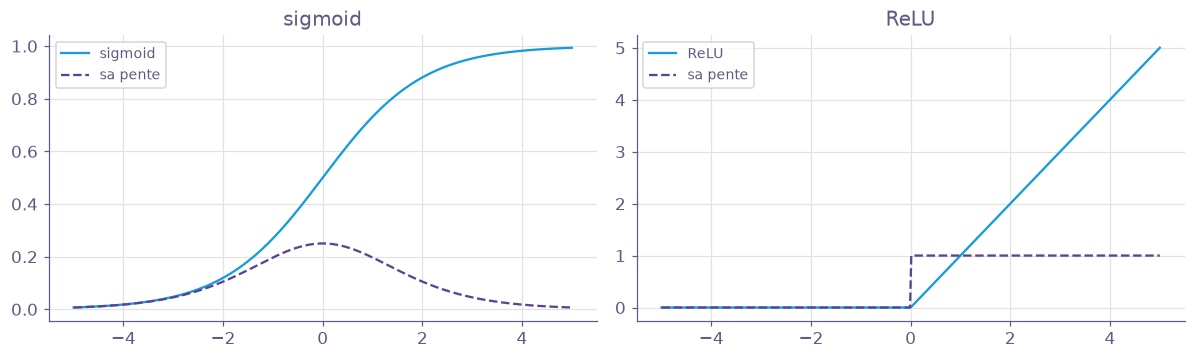

In [11]:
z = np.linspace(-5, 5, 400)
sig = 1 / (1 + np.exp(-z))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
for ax, (nom, f, df) in zip(axes, [("sigmoid", sig, sig * (1 - sig)),
                                   ("ReLU", np.maximum(0, z), (z > 0).astype(float))]):
    ax.plot(z, f, color=BLEU, label=nom)
    ax.plot(z, df, color=VIOLET, linestyle="--", label="sa pente")
    ax.set_title(nom); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

Les courbes en pointillé sont la **pente** de chaque fonction, et c'est elle qui compte.

Pour corriger ses poids, le réseau repart de la sortie vers l'entrée. À chaque couche
traversée, il multiplie sa correction par cette pente.

- **sigmoid** : la pente ne dépasse jamais **0.25** et s'annule sur les bords. La
  correction est donc au moins divisée par 4 à chaque couche, et les premières couches ne
  reçoivent presque plus rien.
- **ReLU** : la pente vaut **1** dès que `z` est positif. La correction traverse sans être
  réduite.

D'où ReLU par défaut.

---
# 4 · Le réseau en PyTorch

L'architecture du matin : **784 → 128 → 64 → 10**.

**Pourquoi 10 sorties et pas une seule ?** Une sortie unique donnant un nombre de 0 à 9
imposerait un ordre : elle serait « moins fausse » en prédisant 7 pour un 8 qu'en prédisant
2. Or un 3 manuscrit n'est pas plus proche d'un 4 que d'un 8. Ce sont 10 catégories, pas
10 quantités.

Le réseau sort donc **10 scores**, un par chiffre, et le plus élevé l'emporte.

**Pourquoi rien après la dernière couche ?** Ces 10 scores ne sont pas des probabilités :
ils peuvent être négatifs et leur somme ne fait pas 1. Les convertir est le travail de
`nn.CrossEntropyLoss`, qui s'en charge tout seul (cette conversion s'appelle un *softmax*,
tu la croiseras partout). On ne met donc rien après le dernier `nn.Linear`.

### D'abord, préparer les données

On recharge MNIST, on met 5 000 images de côté pour la validation, puis on emballe le tout
dans les objets que PyTorch attend.

Deux conversions de type font trébucher tout le monde au début : les images passent en
`.float()` parce que PyTorch calcule en float32, et les étiquettes en `.long()` parce que ce
sont des numéros de classe, pas des valeurs. Le `DataLoader`, lui, découpe en lots de 64 et
remélange à chaque époque, pour que le réseau n'apprenne pas l'ordre des exemples.

La cellule n'affiche presque rien : juste le nombre de lots par époque.

In [12]:
X_train, y_train, X_test, y_test = mnist.charge_mnist(aplati=True, normalise=True)
X_val, y_val = X_train[:5000], y_train[:5000]
X_train, y_train = X_train[5000:], y_train[5000:]


def en_tenseurs(X, y):
    # .float() : PyTorch calcule en float32.
    # .long()  : y est un numéro de classe (0 à 9), donc un entier.
    return TensorDataset(torch.from_numpy(X).float(), torch.from_numpy(y).long())


train_loader = DataLoader(en_tenseurs(X_train, y_train), batch_size=64, shuffle=True)
val_loader = DataLoader(en_tenseurs(X_val, y_val), batch_size=512)
test_loader = DataLoader(en_tenseurs(X_test, y_test), batch_size=512)

# Pour comparer des réglages, un sous-ensemble suffit : on cherche la forme des courbes.
train_rapide = DataLoader(en_tenseurs(X_train[:15000], y_train[:15000]),
                          batch_size=64, shuffle=True)
print(f"{len(train_loader)} lots de 64 par époque")

860 lots de 64 par époque


### Exercice 3 · construire le réseau

`nn.Sequential` empile les couches dans l'ordre : c'est le chemin que suit une image, des
784 pixels jusqu'aux 10 scores.

Chaque `nn.Linear(a, b)` est exactement le `w · x + b` que tu as écrit pour le perceptron,
en plus large : une matrice de poids et un vecteur de biais, avec `a` entrées et `b`
sorties. Tu ne réécris plus la formule, tu déclares les dimensions.

À toi : une couche 784 vers 128, une ReLU, une couche 128 vers 64, une ReLU, une couche
64 vers 10. Rien après la dernière.

En sortie, la structure du réseau s'affiche, et l'assertion vérifie qu'on retrouve bien les
109 386 paramètres comptés au tableau ce matin.

In [14]:
def construit_modele():
    # ✏️ À TOI DE JOUER — empile 784->128, ReLU, 128->64, ReLU, 64->10 (rien après la dernière)
    return nn.Sequential(
        nn.Linear(784, 128),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64, 10)  # Pas de ReLU ni de softmax ici
    )


modele = construit_modele()
n_parametres = sum(p.numel() for p in modele.parameters())
print(modele)
print(f"\nparamètres : {n_parametres:,}".replace(",", " "))
assert n_parametres == 109_386
print("=> 109 386, le compte fait au tableau ce matin.")

Sequential(
  (0): Linear(in_features=784, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=64, bias=True)
  (3): ReLU()
  (4): Linear(in_features=64, out_features=10, bias=True)
)

paramètres : 109 386
=> 109 386, le compte fait au tableau ce matin.


---
# 5 · Entraîner le réseau

La cellule suivante définit deux fonctions, et c'est dans la seconde que tu interviens.

**`evalue`** fait passer des images dans le réseau et mesure la loss et le pourcentage de
bonnes réponses. Comme on ne cherche rien à apprendre ici, `torch.no_grad()` coupe le calcul
des dérivées (plus rapide, moins de mémoire) et `modele.eval()` prévient le réseau qu'il
n'est plus en entraînement.

**`entraine`** est la boucle du matin. Pour chaque lot, elle enchaîne les quatre mêmes
étapes : **forward**, **loss**, **backward**, **update**.

Deux lignes de cette boucle méritent un mot :

`optimizer.zero_grad()` : PyTorch **accumule** les gradients au lieu de les remplacer. Sans
cette ligne, le gradient du lot 2 s'ajoute à celui du lot 1 et le modèle part en vrille,
sans rien signaler.

`loss.backward()` est la seule vraie nouveauté de PyTorch. Il reconstruit tout seul les
dérivées de chaque couche à partir des opérations du forward.

### Exercice 4 · les trois lignes qui manquent

In [18]:
def evalue(modele, loader, critere):
    """Renvoie (loss moyenne, accuracy), sans toucher aux gradients."""
    modele.eval()
    perte, justes, total = 0.0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            z = modele(x)
            perte += critere(z, y).item() * len(y)
            # argmax : l'indice du plus grand score, donc le chiffre prédit.
            justes += (z.argmax(dim=1) == y).sum().item()
            total += len(y)
    return perte / total, justes / total


def entraine(modele, loader, val_loader, eta=0.1, epoques=6, bavard=True):
    critere = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(modele.parameters(), lr=eta)
    historique = {"train": [], "validation": []}

    for epoque in range(epoques):
        modele.train()
        for x, y in loader:
            z = modele(x)                    # 1. forward
            loss = critere(z, y)             # 2. loss

            # ✏️ À TOI DE JOUER — remise à zéro du gradient, backward, update
            optimizer.zero_grad()            # 3. remise à zéro des gradients
            loss.backward()                  # 4. calcul des gradients (rétropropagation)
            optimizer.step()                 # 5. mise à jour des poids

        loss_train, _ = evalue(modele, loader, critere)
        loss_val, acc_val = evalue(modele, val_loader, critere)
        historique["train"].append(loss_train)
        historique["validation"].append(loss_val)
        if bavard:
            print(f"époque {epoque + 1}/{epoques} : loss {loss_train:.4f}, "
                  f"accuracy validation {acc_val:.2%}")

    return historique

On lance 6 passages complets sur les 55 000 images d'entraînement. Chaque ligne affichée est
une époque : la loss doit descendre et l'accuracy de validation monter. C'est le calcul le
plus long du notebook, laisse-le tourner.

époque 1/6 : loss 0.2456, accuracy validation 93.40%
époque 2/6 : loss 0.1555, accuracy validation 95.50%
époque 3/6 : loss 0.1070, accuracy validation 96.64%
époque 4/6 : loss 0.0830, accuracy validation 97.08%
époque 5/6 : loss 0.0653, accuracy validation 97.54%
époque 6/6 : loss 0.0555, accuracy validation 97.54%

accuracy sur le jeu de test : 97.31%


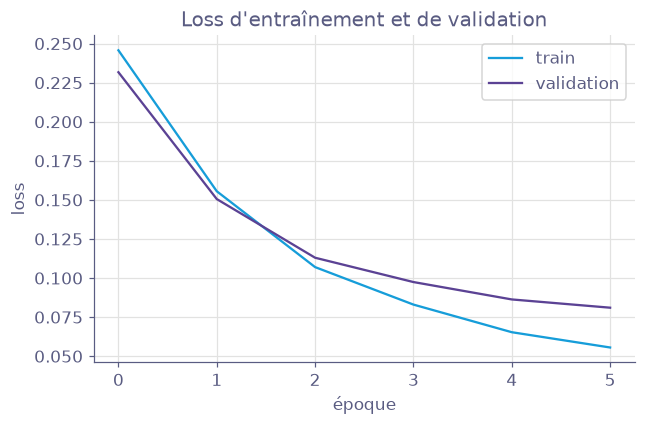

In [19]:
modele = construit_modele()
historique = entraine(modele, train_loader, val_loader, eta=0.1, epoques=6)

_, accuracy = evalue(modele, test_loader, nn.CrossEntropyLoss())
print(f"\naccuracy sur le jeu de test : {accuracy:.2%}")
assert accuracy > 0.96

viz.plot_courbes(historique, titre="Loss d'entraînement et de validation")

La courbe de validation est mesurée sur des images que le réseau n'a jamais vues pendant
l'entraînement. Tant qu'elle descend avec l'autre, le modèle apprend au lieu de mémoriser.

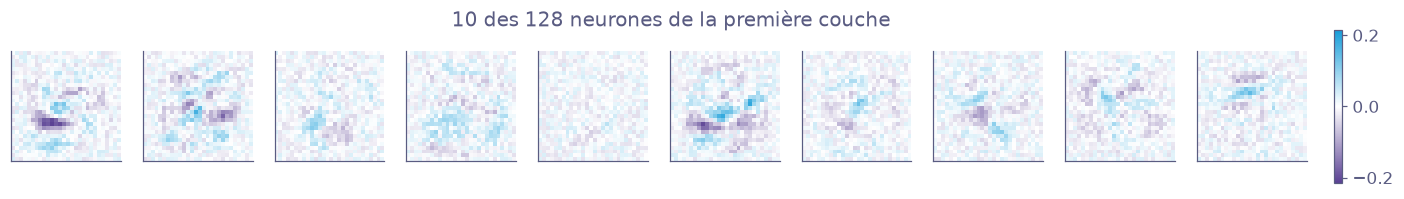

In [20]:
# .detach() : on coupe le lien avec le calcul des gradients pour repasser en NumPy.
# .T        : nn.Linear range ses poids en (sorties, entrées), on remet un neurone par colonne.
W1 = modele[0].weight.detach().numpy()
viz.montre_poids(W1[:10].T, titre="10 des 128 neurones de la première couche")

Moins lisible que le gabarit du perceptron, et c'est normal : aucun de ces neurones ne
détecte « un 3 ». Chacun repère un fragment, et les couches suivantes les combinent.

---
# 6 · Le taux d'apprentissage

C'est l'expérience annoncée ce matin. La règle `w ← w - η · ∂L/∂w` était un dessin, on en
fait une mesure.

La cellule réentraîne quatre fois le même réseau, en ne changeant que `eta`, et superpose les
quatre courbes de loss. Elle part du même tirage aléatoire à chaque fois, donc l'écart
observé vient bien du seul `eta`.

Note ta prédiction pour chaque valeur **avant** de lancer.

eta = 1e-05    : loss finale 2.3037
eta = 0.001    : loss finale 2.2833
eta = 0.1      : loss finale 0.3331
eta = 10.0     : loss finale 2.4064


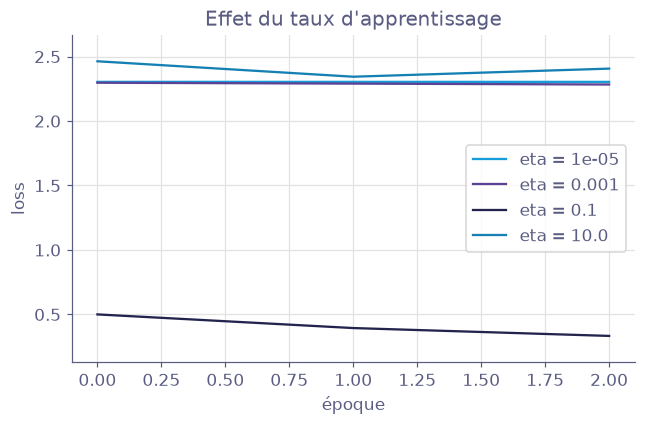

In [22]:
resultats = {}
for eta in [1e-5, 1e-3, 0.1, 10.0]:
    torch.manual_seed(0)                       # même point de départ pour tous
    h = entraine(construit_modele(), train_rapide, val_loader,
                 eta=eta, epoques=3, bavard=False)
    resultats[f"eta = {eta}"] = h["train"]
    fin = h["train"][-1]
    print(f"eta = {eta:<8} : {'diverge' if not np.isfinite(fin) else f'loss finale {fin:.4f}'}")

viz.plot_comparaison(resultats, titre="Effet du taux d'apprentissage")

Repère la valeur **2.30** sur l'axe vertical. Un modèle qui ne sait rien répond 10 % pour
chacune des 10 classes, et la loss vaut alors `-ln(0.1) = ln(10) ≈ 2.30`. C'est le score du
tirage au sort : toute courbe qui y reste n'a rien appris.

| `eta` | Résultat | Interprétation |
|---|---|---|
| `1e-5` | collée à 2.30 | apprend, mais il faudrait des milliers d'époques |
| `1e-3` | décolle à peine | même problème, en moins extrême |
| `0.1` | chute nette | notre réglage |
| `10` | au-dessus de 2.30 | pire que le hasard, les pas sautent par-dessus le minimum |

L'asymétrie est utile en pratique : un `eta` trop petit fait perdre du temps, un `eta` trop
grand empêche d'arriver, quel que soit le temps qu'on y passe.

C'est aussi pour ça qu'Adam est souvent le choix par défaut : il adapte un pas par
paramètre et pardonne un `eta` mal réglé. Tu peux l'essayer dans les bonus.

---
# 7 · Où le modèle se trompe

97 %, c'est un chiffre. Il ne dit pas **où** ça casse.

On fait donc prédire les 10 000 images de test d'un coup, et on croise prédictions et
vraies étiquettes dans une matrice de confusion : la diagonale, ce sont les bonnes réponses,
et tout ce qui déborde est une erreur. La cellule affiche la matrice, puis les trois
confusions les plus fréquentes.

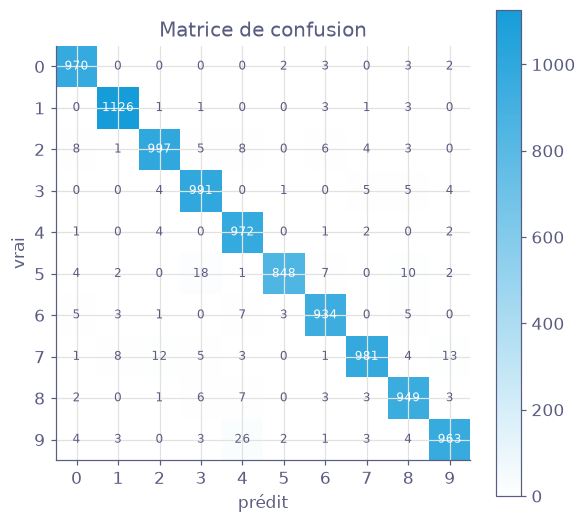

  26 fois : un 9 pris pour un 4
  18 fois : un 5 pris pour un 3
  13 fois : un 7 pris pour un 9


In [23]:
modele.eval()
with torch.no_grad():
    y_pred = modele(torch.from_numpy(X_test).float()).argmax(dim=1).numpy()

matrice = viz.plot_confusion(y_test, y_pred)

erreurs_m = matrice.copy()
np.fill_diagonal(erreurs_m, 0)
for _ in range(3):
    vrai, pred = np.unravel_index(erreurs_m.argmax(), erreurs_m.shape)
    print(f"{erreurs_m[vrai, pred]:4d} fois : un {vrai} pris pour un {pred}")
    erreurs_m[vrai, pred] = 0

269 erreurs sur 10000 images


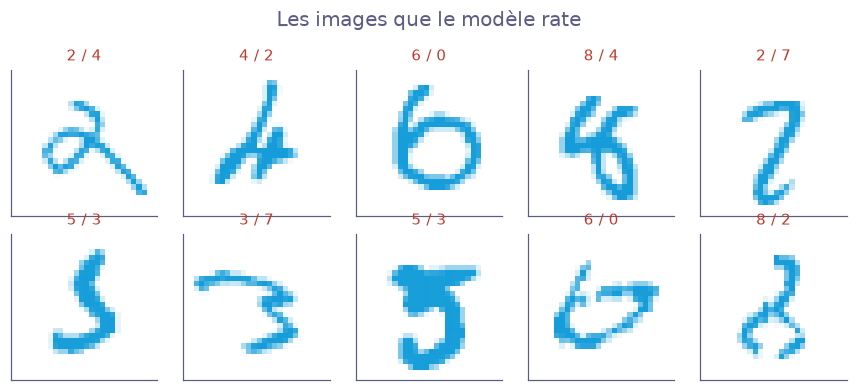

In [24]:
# On isole les images ratées pour les regarder en face.
rates = y_pred != y_test
print(f"{rates.sum()} erreurs sur {len(y_test)} images")
viz.affiche_chiffres(X_test[rates], y_test[rates], y_pred[rates], n=10,
                     titre="Les images que le modèle rate")

Les confusions sont des **4 ↔ 9**, **3 ↔ 5**, **7 ↔ 1**, les paires qu'un humain confond
aussi. Et certaines images sont illisibles : toi non plus tu ne trancherais pas. C'est là
que vit l'**erreur irréductible**, qui tient au bruit des étiquettes et pas au modèle.

---
# 8 · Ce que le modèle n'a jamais appris

Deux expériences courtes sur le réseau déjà entraîné, et un résultat surprenant à la fin.

**Décalons les chiffres de quelques pixels.** `np.roll` glisse chaque image vers la droite,
sans rien changer d'autre. Un humain ne verrait aucune différence. La cellule affiche
l'accuracy pour un décalage de 0 à 4 pixels.

In [25]:
def decale(X, dx):
    return np.roll(X.reshape(-1, 28, 28), shift=dx, axis=2).reshape(-1, 784)


for dx in [0, 1, 2, 3, 4]:
    Xd = decale(X_test, dx)
    with torch.no_grad():
        pred = modele(torch.from_numpy(Xd).float()).argmax(dim=1).numpy()
    print(f"décalage de {dx} px : accuracy {(pred == y_test).mean():.2%}")

décalage de 0 px : accuracy 97.31%
décalage de 1 px : accuracy 95.39%
décalage de 2 px : accuracy 81.91%
décalage de 3 px : accuracy 55.27%
décalage de 4 px : accuracy 33.32%


L'accuracy s'effondre pour deux pixels. Le poids `W1[357, k]` est attaché au pixel 357,
définitivement : si le trait se déplace, le neurone ne le voit plus.

**Le réseau a appris des positions, pas des formes.**

Deuxième expérience : on permute les 784 pixels, la même permutation partout, puis on
réentraîne. Les images deviennent illisibles pour un humain. Prédis le score avant de
lancer.

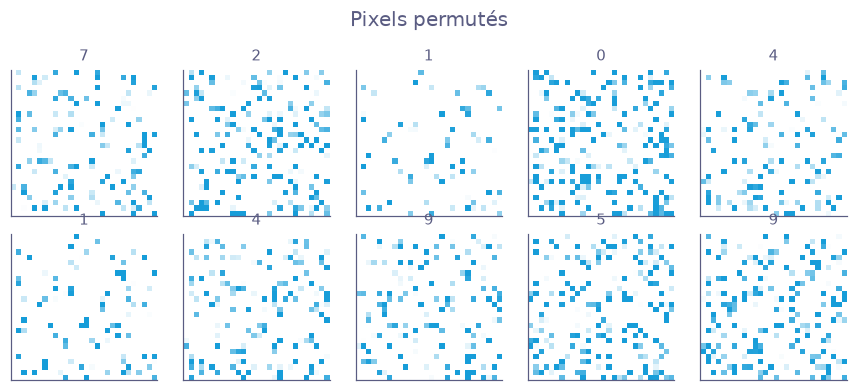

images normales : 93.02%
pixels permutés : 93.38%


In [26]:
permutation = np.random.permutation(784)
viz.affiche_chiffres(X_test[:, permutation], y_test, n=10, titre="Pixels permutés")

resultats_perm = {}
for nom, Xa, Xb in [("images normales", X_train, X_test),
                    ("pixels permutés", X_train[:, permutation], X_test[:, permutation])]:
    torch.manual_seed(0)
    m = construit_modele()
    loader = DataLoader(en_tenseurs(Xa[:20000], y_train[:20000]), batch_size=64, shuffle=True)
    entraine(m, loader, val_loader, eta=0.1, epoques=3, bavard=False)
    with torch.no_grad():
        pred = m(torch.from_numpy(Xb).float()).argmax(dim=1).numpy()
    resultats_perm[nom] = (pred == y_test).mean()
    print(f"{nom} : {resultats_perm[nom]:.2%}")

**Le score est le même.** Le modèle apprend aussi bien sur des images que personne ne peut
lire.

La cause tient dans le `X.reshape(-1, 784)` du début : on y a jeté l'information « ce
pixel est à côté de celui-là ». Pour le réseau, une image est un sac de 784 nombres sans
relation entre eux, et permuter le sac ne lui enlève rien.

Ce n'est pas un bug, c'est la définition d'une couche dense.

---
# 9 · La suite

Les trois problèmes qu'on vient de voir ont une réponse commune.

| Le problème | La réponse |
|---|---|
| il a appris des positions, pas des formes | **filtres locaux** : un détecteur de trait est le même partout |
| 784 × 128 = 100 352 poids pour la seule première couche | **partage des poids** : un filtre 3×3, c'est 9 paramètres réutilisés |
| un décalage de 2 px casse tout | **pooling** : on résume chaque zone, d'où une tolérance aux petits décalages |

Ces trois idées réunies, c'est le **réseau convolutif**. Avec le même budget de calcul il
dépasse 99 % sur MNIST, et il survit au test du décalage.

### Et MNIST lui-même

Trop propre et saturé : chiffres centrés, taille normalisée, fond noir parfait, état de
l'art à 99,8 % depuis des années. Bon terrain d'apprentissage, mauvais indicateur de
performance réelle.

Pour continuer : **Fashion-MNIST** (même format, bien plus dur, ton code marche tel quel),
puis **CIFAR-10**, l'**augmentation de données** et le **transfer learning**.

# À retenir

| | |
|---|---|
| Un neurone trace une frontière | `w` l'oriente, `b` la place |
| Une seule frontière ne suffit pas | XOR le prouve en 4 points |
| La non-linéarité fait la profondeur | sans elle, N couches = 1 couche |
| Apprendre = ajuster θ pour faire baisser L | forward, loss, backward, update |
| La dernière couche sort des scores | `CrossEntropyLoss` les convertit lui-même |
| `eta` se mesure | trop petit : ça rampe. Trop grand : ça n'arrive jamais |
| L'accuracy seule ment | matrice de confusion, et regarder les images ratées |
| Un modèle a une zone de compétence | en dehors, il se trompe avec confiance |

---
# Bonus, si tu as fini

Cellules prêtes à lancer, aucun exercice. Prends celle qui t'intéresse.

Et pour voir qu'il n'y a vraiment pas de magie, le notebook `02_mlp_a_la_main.ipynb` écrit
le même réseau en NumPy pur, forward et backward à la main, avec le gradient vérifié
numériquement.

In [ ]:
# A. L'effet de /255, mesuré.
X_brut, y_brut, _, _ = mnist.charge_mnist(aplati=True, normalise=False, sous_ensemble=[0, 1])
_, _, err_brut = entraine_perceptron(X_brut, y_brut, eta=0.01, epoques=3)
_, _, err_norm = entraine_perceptron(X_train01, y_train01, eta=0.01, epoques=3)
viz.plot_comparaison({"pixels /255": err_norm, "pixels bruts (0 à 255)": err_brut},
                     titre="Avec et sans normalisation", ylabel="erreurs par époque")

In [ ]:
# B. SGD contre Adam, à eta identique.
comparaison = {}
for nom, fabrique in [("SGD", torch.optim.SGD), ("Adam", torch.optim.Adam)]:
    torch.manual_seed(0)
    m, critere = construit_modele(), nn.CrossEntropyLoss()
    opt = fabrique(m.parameters(), lr=0.01)
    pertes = []
    for _ in range(3):
        m.train()
        for x, y in train_rapide:
            opt.zero_grad(); critere(m(x), y).backward(); opt.step()
        pertes.append(evalue(m, train_rapide, critere)[0])
    comparaison[nom] = pertes
    print(f"{nom:5} : loss finale {pertes[-1]:.4f}")

viz.plot_comparaison(comparaison, titre="SGD contre Adam, à eta identique")

In [ ]:
# C. Plus gros, est-ce mieux ? Regarde aussi le nombre de paramètres.
# 6 époques et pas 3 : en dessous, l'ordre des résultats n'est que du bruit.
for taille in [16, 128, 1024]:
    torch.manual_seed(0)
    m = nn.Sequential(nn.Linear(784, taille), nn.ReLU(),
                      nn.Linear(taille, 64), nn.ReLU(), nn.Linear(64, 10))
    entraine(m, train_rapide, val_loader, eta=0.1, epoques=6, bavard=False)
    _, acc = evalue(m, test_loader, nn.CrossEntropyLoss())
    print(f"{taille:5} neurones : {acc:.2%} de test, "
          f"{sum(p.numel() for p in m.parameters()):,} paramètres".replace(",", " "))

In [ ]:
# D. Quand l'accuracy ment : un jeu où 95 % des exemples sont des 1.
masque_1 = y_test == 1
y_desequilibre = np.concatenate([y_test[masque_1], y_test[~masque_1][:60]])
print(f"accuracy du modèle « je réponds toujours 1 » : {(y_desequilibre == 1).mean():.2%}")
print("=> 95 %, sans jamais regarder l'image.")

In [ ]:
# E. Ton propre chiffre. MNIST est centré, normalisé en taille, blanc sur noir.
mon_chiffre = np.zeros((28, 28), dtype=np.float32)
mon_chiffre[6, 7:20] = 1.0                          # la barre du haut
for i, ligne in enumerate(range(7, 22)):
    mon_chiffre[ligne, 19 - int(i * 0.7)] = 1.0     # la diagonale

# Avec ton propre PNG :
#   from PIL import Image
#   img = Image.open("mon_chiffre.png").convert("L").resize((28, 28))
#   mon_chiffre = 1.0 - np.array(img, dtype=np.float32) / 255.0

plt.figure(figsize=(3, 3))
plt.imshow(mon_chiffre, cmap="gray_r"); plt.axis("off"); plt.show()

with torch.no_grad():
    probas = torch.softmax(modele(torch.from_numpy(mon_chiffre.reshape(1, 784))), dim=1)[0]
print("prédiction :", int(probas.argmax()), f"(confiance {probas.max():.1%})")
print("Souvent faux, et avec confiance : c'est le décalage de distribution.")